In [1]:
# Write a Python Program to implement reverse image search engine using keras.

In [1]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras.preprocessing import image
import os
import cv2
import matplotlib.pyplot as plt

2026-04-20 21:14:55.899993: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-20 21:14:55.903159: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-20 21:14:55.962686: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-20 21:14:55.965399: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-20 21:14:57.357836: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not fin

In [2]:
model = VGG16(weights="imagenet", include_top=False, pooling='avg')

In [ ]:
def extract_features(img):
    img = image.load_img(img, target_size = (224,224))
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis = 0)
    img = preprocess_input(img)
    img = model.predict(img)
    return img.flatten()

In [ ]:
dataset_path = "../cv_lab/Mar 11/caltech101"
image_paths = []
features = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".jpg"):
            path = os.path.join(root, file)
            image_paths.append(path)
            feats = extract_features(path)
            features.append(feats)

features = np.array(features)

In [11]:
features = features.reshape(-1, 512)

1/1 [==============================] - 0s 227ms/step


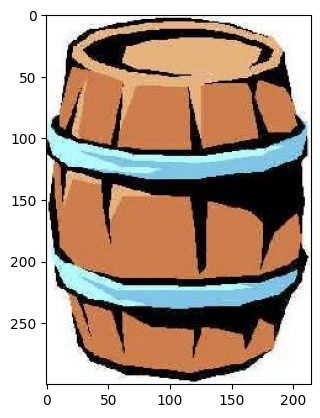

In [18]:
query_img = image_paths[100]
query_feats = extract_features(query_img)
similarities = cosine_similarity([query_feats], features)[0]
top_indices = np.argsort(similarities)[::-1][:5]
img = cv2.imread(query_img)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

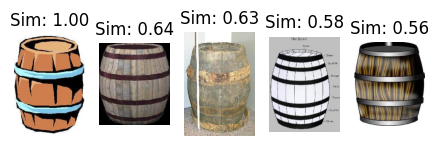

In [20]:
for i in range(len(top_indices)):
    plt.subplot(1, 6, i+2)
    img = cv2.imread(image_paths[top_indices[i]])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Sim: {similarities[top_indices[i]]:.2f}")
plt.show()

In [9]:
top_indices

array([100, 107, 120, 105, 119])